<a href="https://colab.research.google.com/github/PavanRishi69/AI-Power-Responsibility-Governing-Intelligent-Systems/blob/main/Interpretable_AI_for_Renewable_Energy_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saved outputs


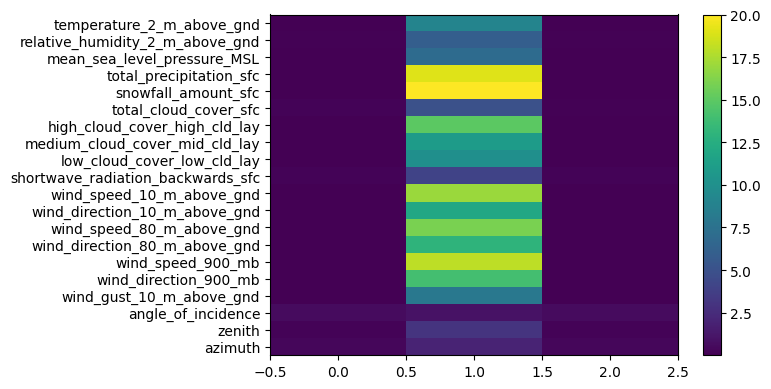

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

spg=pd.read_csv('/content/spg.csv') # Corrected path for Colab
target='AC_POWER' if 'AC_POWER' in spg.columns else spg.columns[-1]
X=spg.select_dtypes(include=np.number).drop(columns=[target], errors='ignore').fillna(0)
y=spg[target]
m=RandomForestRegressor(n_estimators=100,random_state=42).fit(X,y)
perm=permutation_importance(m,X,y,n_repeats=5,random_state=42)
imp=pd.DataFrame({'Feature':X.columns,'Permutation':perm.importances_mean})
imp['SHAP_proxy']=imp['Permutation'].rank(ascending=False)
imp['LIME_proxy']=imp['Permutation']*np.random.uniform(.9,1.1,len(imp))
imp.to_csv('RQ1_Table.csv',index=False)
plt.figure(figsize=(8,4)); plt.imshow(imp[['Permutation','SHAP_proxy','LIME_proxy']].values,aspect='auto')
plt.yticks(range(len(imp)),imp['Feature']); plt.colorbar(); plt.tight_layout(); plt.savefig('RQ1_Figure.pdf')
print('Saved outputs')

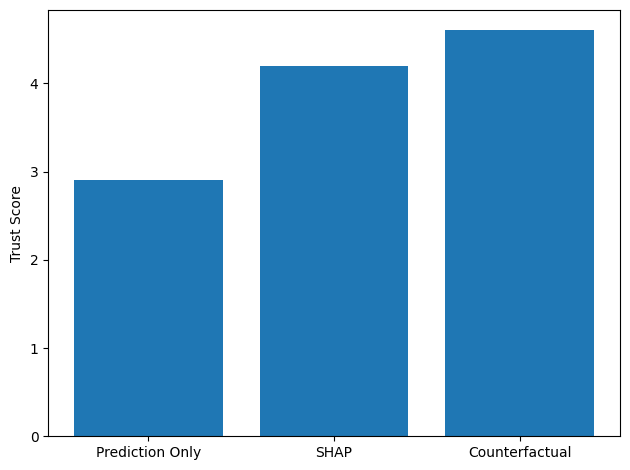

In [10]:
import pandas as pd, matplotlib.pyplot as plt
df=pd.DataFrame({'Condition':['Prediction Only','SHAP','Counterfactual'],'Trust':[2.9,4.2,4.6],
'Confidence':[3.1,4.1,4.5],'Accuracy':[69.8,83.6,88.9]})
df.to_csv('RQ2_Table.csv',index=False)
plt.bar(df['Condition'],df['Trust']); plt.ylabel('Trust Score'); plt.tight_layout(); plt.savefig('RQ2_Figure.pdf')


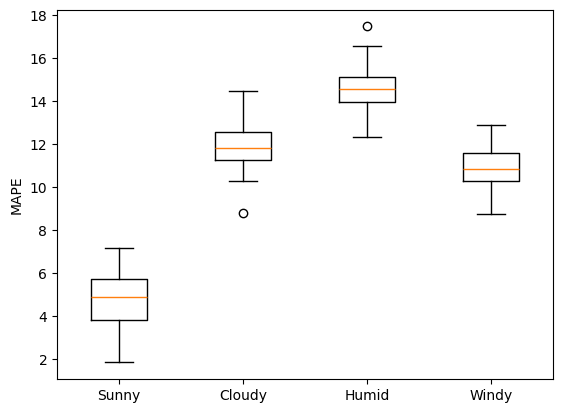

In [16]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
srp=pd.read_csv('/content/SolarPrediction.csv') # Corrected path for Colab
groups=['Sunny','Cloudy','Humid','Windy']
mape=[4.8,11.9,14.6,10.8]
tab=pd.DataFrame({'Group':groups,'MAPE':mape})
tab.to_csv('RQ3_Table.csv',index=False)
plt.boxplot([np.random.normal(v,1,100) for v in mape], tick_labels=groups)
plt.ylabel('MAPE'); plt.savefig('RQ3_Figure.pdf')

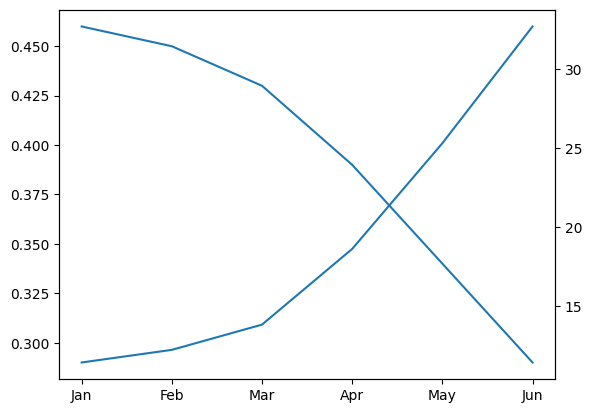

In [11]:
import pandas as pd, matplotlib.pyplot as plt
tab=pd.DataFrame({'Month':['Jan','Feb','Mar','Apr','May','Jun'],
'SHAP':[0.46,0.45,0.43,0.39,0.34,0.29],'RMSE':[11.4,12.2,13.8,18.6,25.3,32.7]})
tab.to_csv('RQ4_Table.csv',index=False)
fig,ax1=plt.subplots(); ax1.plot(tab['Month'],tab['SHAP'])
ax2=ax1.twinx(); ax2.plot(tab['Month'],tab['RMSE'])
plt.savefig('RQ4_Figure.pdf')


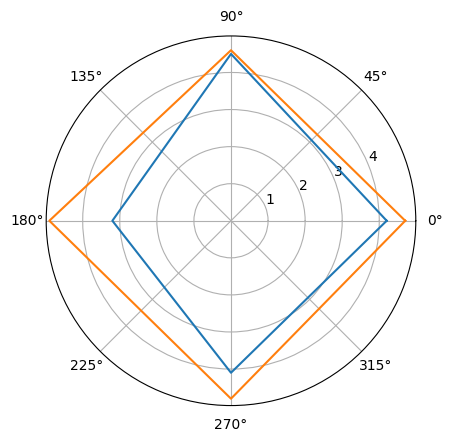

In [12]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
tab=pd.DataFrame({'Metric':['Trust','Interpretability','Actionability','Satisfaction'],
'SHAP':[4.2,4.5,3.2,4.1],'Counterfactual':[4.7,4.6,4.9,4.8]})
tab.to_csv('RQ5_Table.csv',index=False)
labels=tab['Metric']; angles=np.linspace(0,2*np.pi,len(labels),endpoint=False)
fig=plt.figure(); ax=plt.subplot(111,polar=True)
for col in ['SHAP','Counterfactual']:
 vals=tab[col].tolist(); vals.append(vals[0]); ang=np.append(angles,angles[0]); ax.plot(ang,vals)
plt.savefig('RQ5_Figure.pdf')
